.
# S&P 500 ESG Risk Ratings

Import libraries and load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from scipy.stats import f_oneway

# For modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# Settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('ggplot')  

# Load the dataset
esg = pd.read_csv('SP 500 ESG Risk Ratings.csv')
print(esg.head())
print('\nDataset shape:', esg.shape)
print('\nColumn names:', esg.columns.tolist())


  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2              Restaurants               6,500   
3   Software - Application               9,084   
4  Medical Care Facilities              70,000   

                   

## Data Cleaning and Preparation 

In [4]:
# Create cleaned dataset 
esg_clean=esg.copy()

# Rename columns for easier handling
esg_clean.rename(columns={
    'Symbol':'Ticker',
    'Total ESG Risk score':'TotalEsg',
    'Environment Risk Score':'EnvRisk',
    'Governance Risk Score':'GovRisk',
    'Social Risk Score':'SocialRisk',
}, inplace=True)

# Drop missing values
esg_clean=esg_clean.dropna(subset=['TotalEsg', 'EnvRisk', 'GovRisk', 'SocialRisk', 'Sector'])

print('Cleaned dataset shape:', esg_clean.shape)
print('\nMissing values:')
print(esg_clean[['TotalEsg', 'EnvRisk', 'GovRisk', 'SocialRisk', 'Sector']].isnull().sum())
print('\nSector distribution:')
print(esg_clean['Sector'].value_counts())

Cleaned dataset shape: (430, 15)

Missing values:
TotalEsg      0
EnvRisk       0
GovRisk       0
SocialRisk    0
Sector        0
dtype: int64

Sector distribution:
Sector
Financial Services        63
Technology                61
Industrials               60
Healthcare                53
Consumer Cyclical         51
Consumer Defensive        33
Real Estate               28
Utilities                 28
Energy                    20
Basic Materials           19
Communication Services    14
Name: count, dtype: int64


## Exploratory Data Analysis

Correlation between ESG Risk Scores:
             EnvRisk   GovRisk  SocialRisk  TotalEsg
EnvRisk     1.000000 -0.220337    0.066318  0.703659
GovRisk    -0.220337  1.000000    0.357514  0.347539
SocialRisk  0.066318  0.357514    1.000000  0.694264
TotalEsg    0.703659  0.347539    0.694264  1.000000


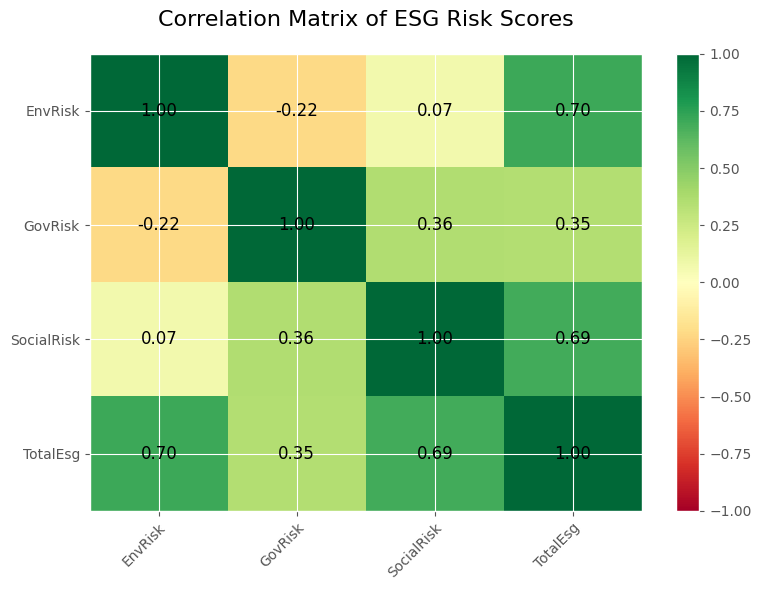

In [5]:
# Correlation analysis
print('Correlation between ESG Risk Scores:')
corr_matrix = esg_clean[['EnvRisk', 'GovRisk', 'SocialRisk', 'TotalEsg']].corr()
print(corr_matrix)

# Visualize correlations using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=12)

ax.set_title('Correlation Matrix of ESG Risk Scores', fontsize=16, pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

/var/folders/qr/x_nlp43d3qn8r4dfyjvcx7xw0000gn/T/ipykernel_9012/2684654810.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(data_env, labels=sectors)
/var/folders/qr/x_nlp43d3qn8r4dfyjvcx7xw0000gn/T/ipykernel_9012/2684654810.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(data_gov, labels=sectors)
/var/folders/qr/x_nlp43d3qn8r4dfyjvcx7xw0000gn/T/ipykernel_9012/2684654810.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_social, labels=sectors)
/var/folders/qr/x_nlp43d3qn8r4dfyjvcx7xw0000gn/T/ipykernel_9012/2684654810.py:34: MatplotlibDeprecationW

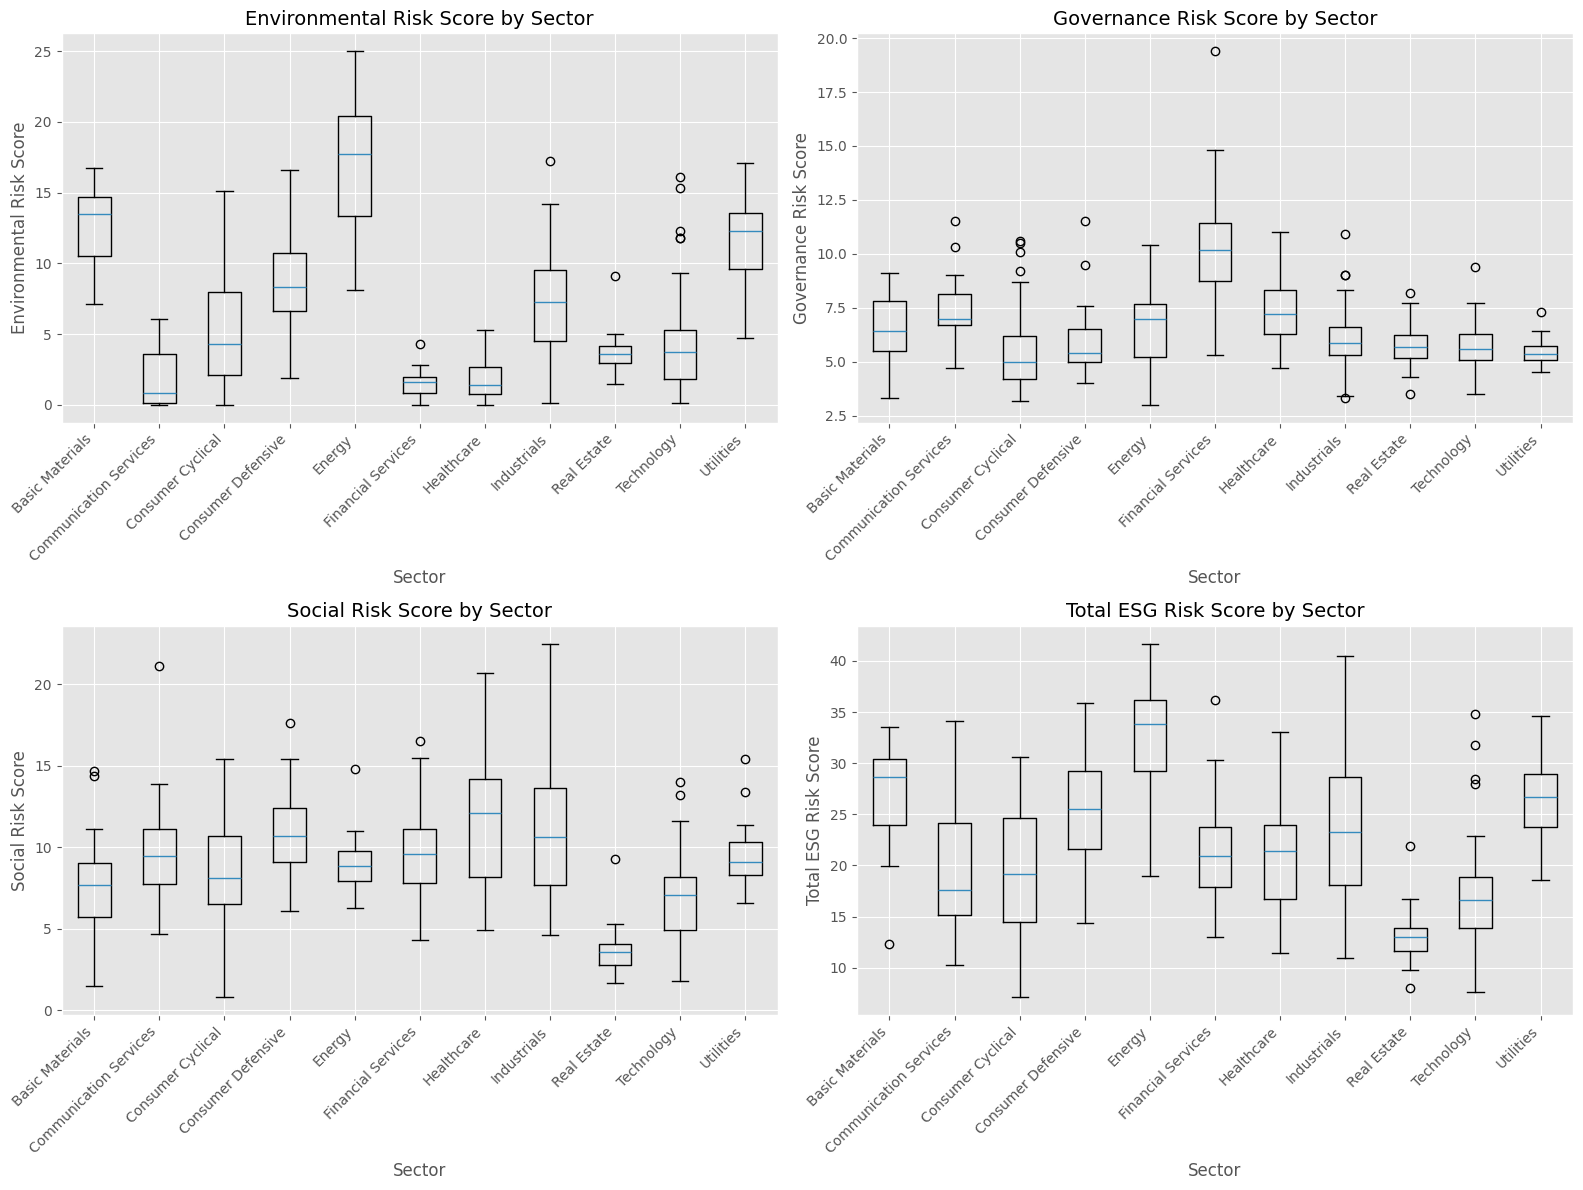

In [6]:
# ESG Risk Scores by Sector using boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get unique sectors
sectors = sorted(esg_clean['Sector'].unique())

# Environmental Risk by Sector
data_env = [esg_clean[esg_clean['Sector'] == sector]['EnvRisk'].values for sector in sectors]
axes[0, 0].boxplot(data_env, labels=sectors)
axes[0, 0].set_title('Environmental Risk Score by Sector', fontsize=14)
axes[0, 0].set_xlabel('Sector', fontsize=12)
axes[0, 0].set_ylabel('Environmental Risk Score', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Governance Risk by Sector
data_gov = [esg_clean[esg_clean['Sector'] == sector]['GovRisk'].values for sector in sectors]
axes[0, 1].boxplot(data_gov, labels=sectors)
axes[0, 1].set_title('Governance Risk Score by Sector', fontsize=14)
axes[0, 1].set_xlabel('Sector', fontsize=12)
axes[0, 1].set_ylabel('Governance Risk Score', fontsize=12)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Social Risk by Sector
data_social = [esg_clean[esg_clean['Sector'] == sector]['SocialRisk'].values for sector in sectors]
axes[1, 0].boxplot(data_social, labels=sectors)
axes[1, 0].set_title('Social Risk Score by Sector', fontsize=14)
axes[1, 0].set_xlabel('Sector', fontsize=12)
axes[1, 0].set_ylabel('Social Risk Score', fontsize=12)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Total ESG Risk by Sector
data_total = [esg_clean[esg_clean['Sector'] == sector]['TotalEsg'].values for sector in sectors]
axes[1, 1].boxplot(data_total, labels=sectors)
axes[1, 1].set_title('Total ESG Risk Score by Sector', fontsize=14)
axes[1, 1].set_xlabel('Sector', fontsize=12)
axes[1, 1].set_ylabel('Total ESG Risk Score', fontsize=12)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Mean ESG Risk Scores by Sector:
                          EnvRisk    GovRisk  SocialRisk   TotalEsg
Sector                                                             
Energy                  16.925000   6.495000    8.925000  32.335000
Basic Materials         12.615789   6.568421    7.542105  26.715789
Utilities               11.810714   5.471429    9.435714  26.710714
Consumer Defensive       8.733333   5.866667   10.836364  25.445455
Industrials              7.100000   6.076667   10.841667  24.013333
Financial Services       1.411111  10.144444    9.631746  21.190476
Healthcare               1.790566   7.309434   11.475472  20.577358
Communication Services   1.857143   7.414286   10.142857  19.414286
Consumer Cyclical        5.300000   5.552941    8.388235  19.227451
Technology               4.288525   5.757377    6.878689  16.924590
Real Estate              3.689286   5.750000    3.635714  13.085714


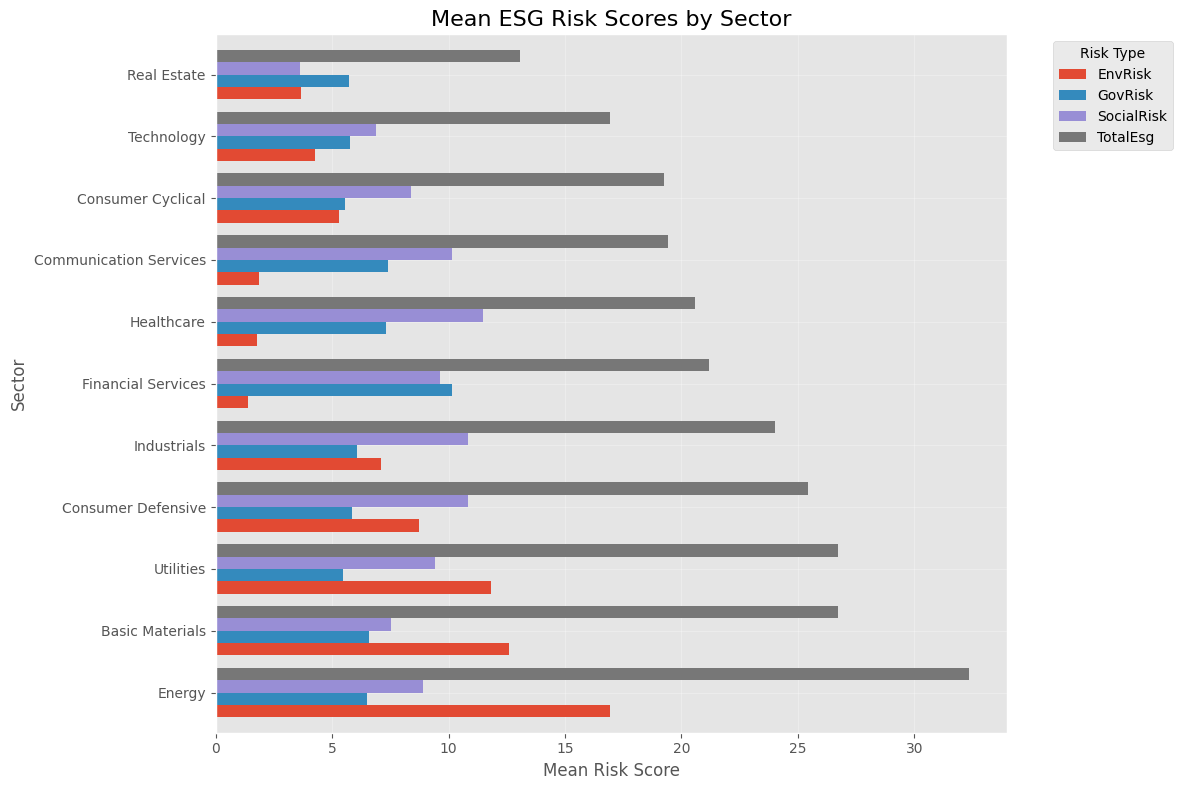

In [7]:
# Mean ESG Scores by Sector
sector_means = esg_clean.groupby('Sector')[['EnvRisk', 'GovRisk', 'SocialRisk', 'TotalEsg']].mean()
sector_means = sector_means.sort_values('TotalEsg', ascending=False)

print('Mean ESG Risk Scores by Sector:')
print(sector_means)

# Visualize using pandas plotting (built-in matplotlib)
ax = sector_means.plot(kind='barh', figsize=(12, 8), width=0.8)
ax.set_xlabel('Mean Risk Score', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Mean ESG Risk Scores by Sector', fontsize=16)
ax.legend(title='Risk Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Random Forest Classification Model

### Step 1: Prepare Features and Target

In [8]:
# Define features (X) and target (y)
X = esg_clean[['EnvRisk', 'GovRisk', 'SocialRisk']]
y = esg_clean['Sector']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature statistics:')
print(X.describe())
print('\nNumber of classes (sectors):', y.nunique())
print('\nClass distribution:')
print(y.value_counts())

Features shape: (430, 3)
Target shape: (430,)

Feature statistics:
          EnvRisk     GovRisk  SocialRisk
count  430.000000  430.000000  430.000000
mean     5.739767    6.725116    9.070465
std      5.092421    2.208085    3.657924
min      0.000000    3.000000    0.800000
25%      1.800000    5.300000    6.700000
50%      4.050000    6.100000    8.900000
75%      8.950000    7.675000   11.200000
max     25.000000   19.400000   22.500000

Number of classes (sectors): 11

Class distribution:
Sector
Financial Services        63
Technology                61
Industrials               60
Healthcare                53
Consumer Cyclical         51
Consumer Defensive        33
Real Estate               28
Utilities                 28
Energy                    20
Basic Materials           19
Communication Services    14
Name: count, dtype: int64


### Step 2: Train-Test Split

In [9]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])
print('\nTraining set sector distribution:')
print(y_train.value_counts())
print('\nTesting set sector distribution:')
print(y_test.value_counts())

Training set size: 344
Testing set size: 86

Training set sector distribution:
Sector
Financial Services        50
Technology                49
Industrials               48
Healthcare                43
Consumer Cyclical         41
Consumer Defensive        27
Real Estate               22
Utilities                 22
Energy                    16
Basic Materials           15
Communication Services    11
Name: count, dtype: int64

Testing set sector distribution:
Sector
Financial Services        13
Technology                12
Industrials               12
Consumer Cyclical         10
Healthcare                10
Utilities                  6
Real Estate                6
Consumer Defensive         6
Basic Materials            4
Energy                     4
Communication Services     3
Name: count, dtype: int64


### Step 3: Baseline Random Forest Model

In [10]:
# Create baseline Random Forest model
rf_baseline = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all CPU cores
)

# Train the model
print('Training baseline Random Forest model...')
rf_baseline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_pred_proba_baseline = rf_baseline.predict_proba(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f'\nBaseline Model Accuracy: {baseline_accuracy:.4f}')

Training baseline Random Forest model...

Baseline Model Accuracy: 0.5814


### Step 4: Model Evaluation

In [11]:
# Detailed classification report
print('Classification Report:')
print('=' * 70)
print(classification_report(y_test, y_pred_baseline))

# Overall metrics
print('\nOverall Metrics:')
print('=' * 70)
print(f'Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision (weighted): {precision_score(y_test, y_pred_baseline, average="weighted"):.4f}')
print(f'Recall (weighted): {recall_score(y_test, y_pred_baseline, average="weighted"):.4f}')
print(f'F1-Score (weighted): {f1_score(y_test, y_pred_baseline, average="weighted"):.4f}')

Classification Report:
                        precision    recall  f1-score   support

       Basic Materials       1.00      0.25      0.40         4
Communication Services       1.00      0.33      0.50         3
     Consumer Cyclical       0.38      0.30      0.33        10
    Consumer Defensive       0.43      0.50      0.46         6
                Energy       1.00      0.75      0.86         4
    Financial Services       0.81      1.00      0.90        13
            Healthcare       0.73      0.80      0.76        10
           Industrials       0.38      0.25      0.30        12
           Real Estate       0.62      0.83      0.71         6
            Technology       0.44      0.67      0.53        12
             Utilities       0.40      0.33      0.36         6

              accuracy                           0.58        86
             macro avg       0.65      0.55      0.56        86
          weighted avg       0.59      0.58      0.56        86


Overall Metri

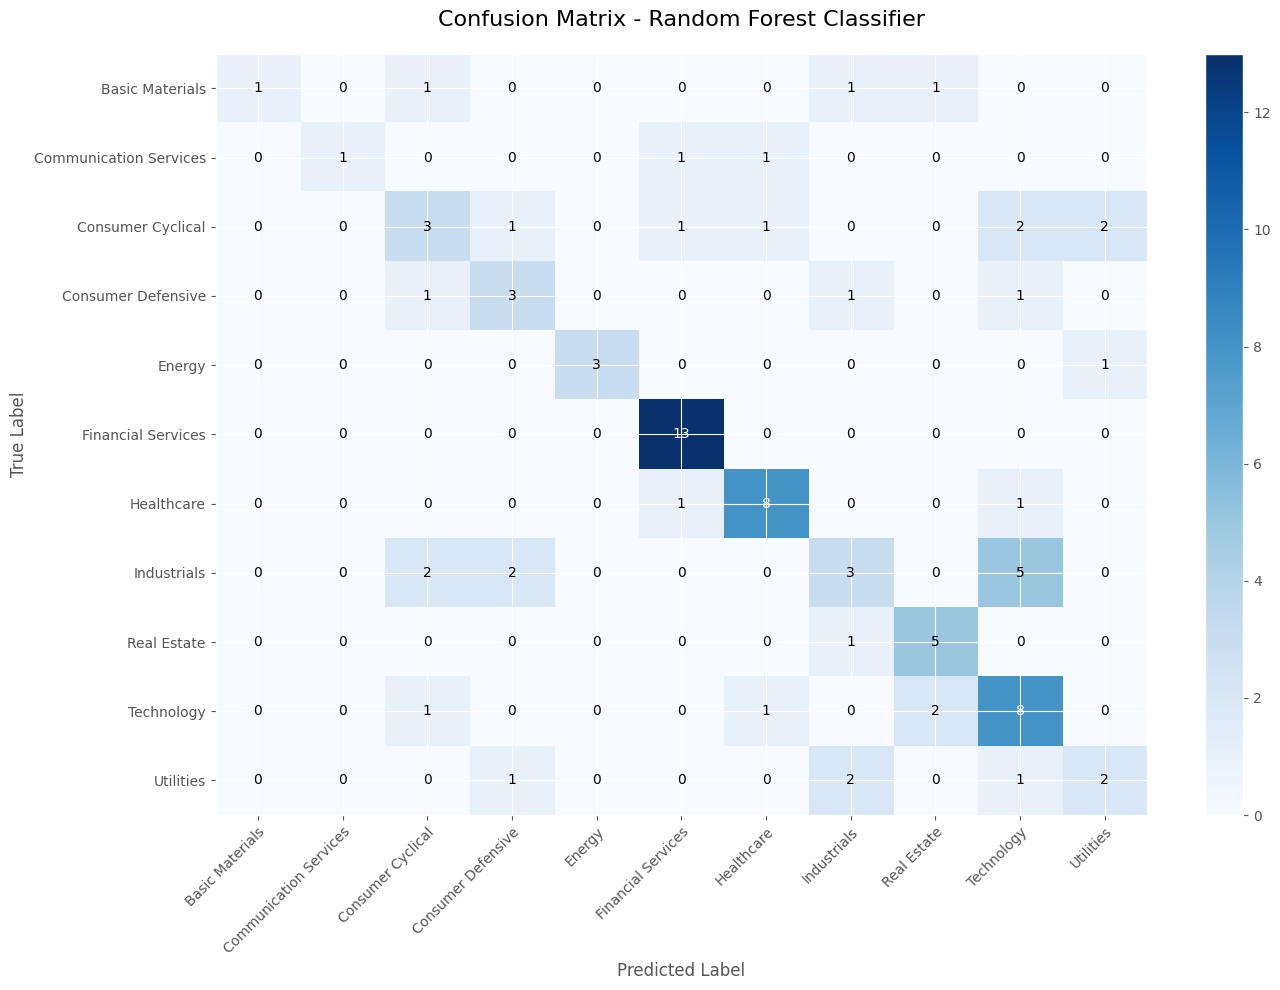

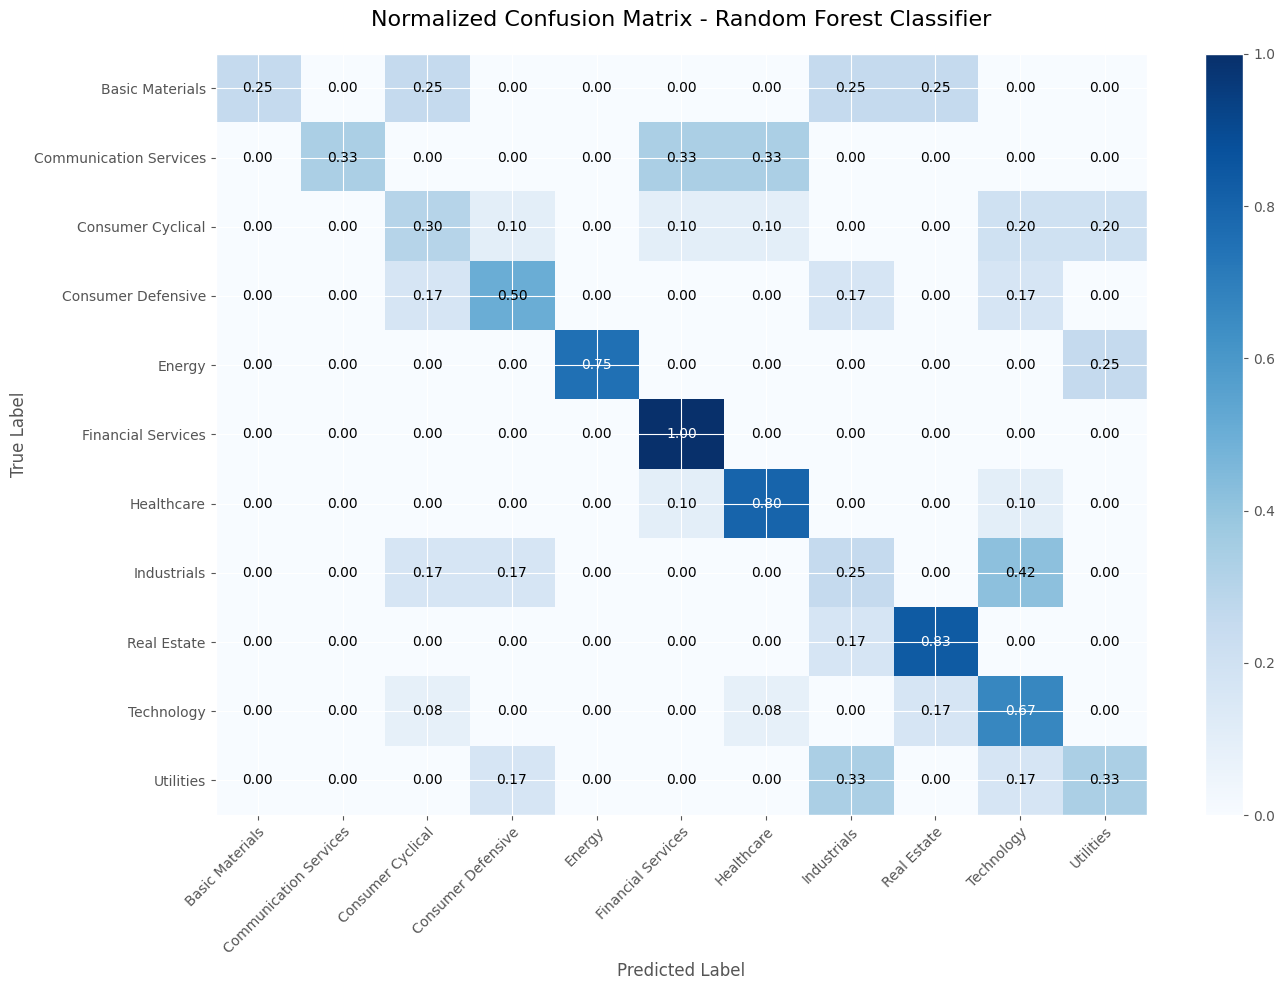

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
classes = rf_baseline.classes_

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=10)

ax.set_title('Confusion Matrix - Random Forest Classifier', fontsize=16, pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        text = ax.text(j, i, f'{cm_normalized[i, j]:.2f}',
                      ha="center", va="center", 
                      color="white" if cm_normalized[i, j] > 0.5 else "black",
                      fontsize=10)

ax.set_title('Normalized Confusion Matrix - Random Forest Classifier', fontsize=16, pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Step 5: Feature Importance Analysis

Feature Importance Rankings:
      Feature  Importance
0     EnvRisk    0.350974
1     GovRisk    0.327365
2  SocialRisk    0.321661


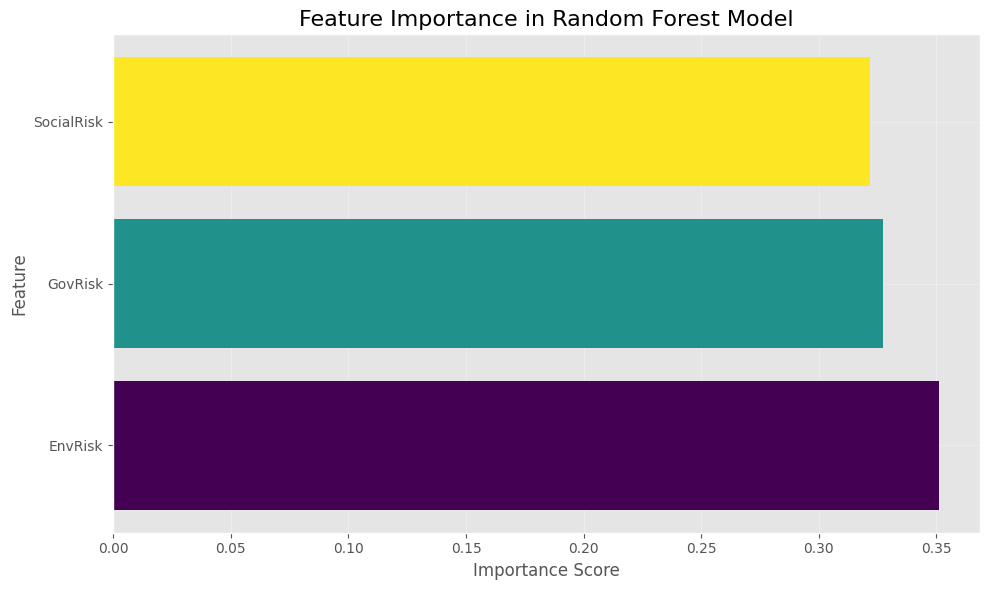

In [13]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance Rankings:')
print(feature_importance)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance in Random Forest Model', fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6: Cross-Validation

Performing 5-fold cross-validation...

Cross-Validation Results:
Individual fold scores: [0.45348837 0.5        0.51162791 0.45348837 0.52325581]
Mean CV Accuracy: 0.4884
Standard Deviation: 0.0294
95% Confidence Interval: [0.4307, 0.5460]


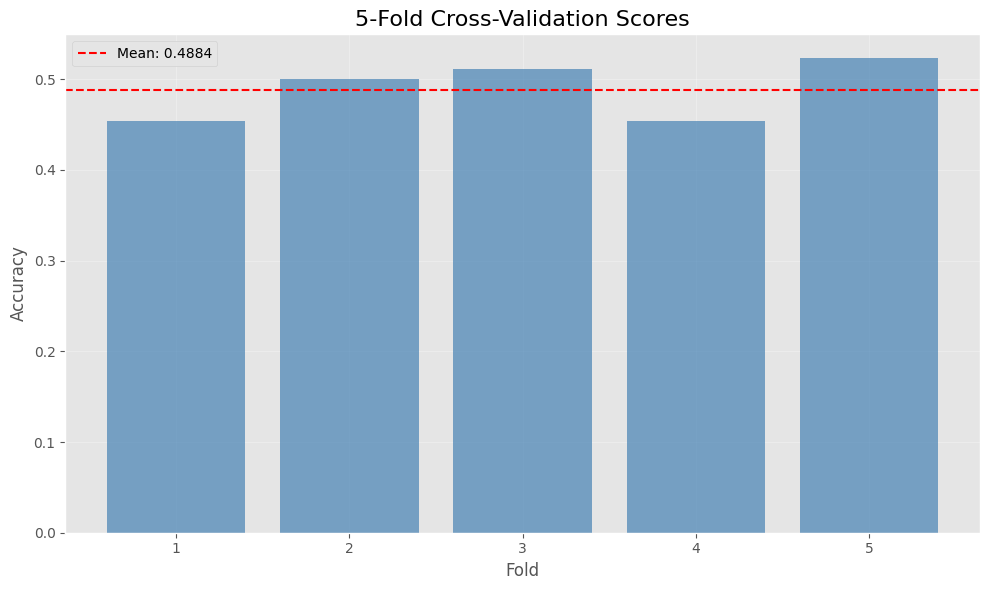

In [14]:
# Perform 5-fold cross-validation
print('Performing 5-fold cross-validation...')
cv_scores = cross_val_score(rf_baseline, X, y, cv=5, scoring='accuracy')

print('\nCross-Validation Results:')
print('=' * 50)
print(f'Individual fold scores: {cv_scores}')
print(f'Mean CV Accuracy: {cv_scores.mean():.4f}')
print(f'Standard Deviation: {cv_scores.std():.4f}')
print(f'95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]')

# Visualize CV scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7)
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross-Validation Scores', fontsize=16)
ax.set_xticks(range(1, 6))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()